# Exploratory Data Analysis and Monitoring

This notebook marks the transition from data validation into behavioral analysis.

In the previous stages of the project, the dataset was checked for structural integrity, data types, missing values, duplicate rows, and basic quality concerns. Those steps were necessary to confirm that the data could be trusted for deeper analysis.

This notebook moves beyond the question of whether the dataset is structurally usable and begins addressing a more important analytical question: how does fraud actually behave inside this transaction system?

The purpose of this notebook is to build a broad, evidence-based understanding of transaction behavior, fraud concentration, and monitoring patterns across the full dataset.

This part has several objectives:

- summarize the overall size and financial scale of the dataset
- understand how transaction types differ in volume and fraud exposure
- compare fraud and non-fraud transactions in terms of amount and account balances
- evaluate how useful the built-in fraud flag is compared with the actual fraud label
- study activity patterns at the origin and destination account level
- create hourly and daily monitoring tables that show how risk changes over time
- identify potential spikes or unusual periods in fraud activity
- save structured outputs that will support feature engineering and later modeling

This notebook is important because good feature engineering should not begin from guesswork. It should begin from observed patterns in the data. The analysis here is designed to uncover those patterns in a disciplined and transparent way.

## 1. Preparing the notebook environment

This first step prepares the notebook environment and ensures that the project files and reusable source code can be accessed correctly.

The notebook is being run from within the project structure rather than as a standalone script, so it needs to identify the correct project root and add that location to Python's import path. This allows the notebook to import the reusable data-loading functions defined earlier in the project.

This step also imports the main libraries used throughout the notebook:

- `numpy` for numerical calculations
- `pandas` for working with tabular data
- `matplotlib` for building charts

Finally, the notebook sets display options so that larger tables and numerical outputs are easier to read while exploring the full dataset.

In [5]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Defining the dataset and output locations

This step defines where the notebook should find the raw dataset and where it should save the outputs produced during this phase.

Two directories are important here:

- the raw-data directory, which contains the PaySim transaction dataset
- the output directory, which will store tables generated from this notebook

The notebook also creates the Phase 3 output folder if it does not already exist. This is a useful project-management step because it keeps the outputs from different stages organized and makes the workflow easier to reproduce.

Before proceeding, the notebook prints the selected file name and confirms that the dataset file exists. This helps ensure that the analysis is running against the correct input.

In [6]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "phase_3_eda_monitoring"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR / "paysim dataset.csv"

print("Selected file:", DATA_PATH.name)
print("File exists:", DATA_PATH.exists())

Selected file: paysim dataset.csv
File exists: True


## 3. Importing the reusable full-dataset loader

This notebook uses a reusable data-loading function from the project source code instead of directly writing the CSV loading logic again.

This is an intentional design choice. By centralizing the loading logic in a source module, the project becomes cleaner and easier to maintain. If the loading method ever needs to change, it can be updated in one place rather than across multiple notebooks.

The imported function has already been designed to use optimized data types, which is especially important for a dataset with more than six million rows.

In [7]:
from src.preprocessing import load_full_dataset

## 4. Loading the full dataset

This step loads the complete transaction dataset into memory.

The notebook then prints the shape of the loaded data and displays the first few records. This serves several purposes:

- confirms that the full dataset was loaded successfully
- verifies that the number of rows and columns matches expectations
- gives a concrete preview of what a transaction record looks like at the raw row level

This is an important transition point in the notebook. From this point onward, the analysis is being performed on the full dataset rather than on a small validation sample.

In [47]:
df = load_full_dataset(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.640",C1231006815,"170,136.000","160,296.359",M1979787155,0.000,0.000,0,0
1,1,PAYMENT,"1,864.280",C1666544295,"21,249.000","19,384.721",M2044282225,0.000,0.000,0,0
2,1,TRANSFER,181.000,C1305486145,181.000,0.000,C553264065,0.000,0.000,1,0
3,1,CASH_OUT,181.000,C840083671,181.000,0.000,C38997010,"21,182.000",0.000,1,0
4,1,PAYMENT,"11,668.140",C2048537720,"41,554.000","29,885.859",M1230701703,0.000,0.000,0,0


## 5. Running a structural sanity check on the full dataset

This step displays the structural summary of the full DataFrame.

The output provides a compact view of:

- the number of rows
- the number of columns
- the assigned data type of each field
- the total memory usage of the in-memory dataset

Although the dataset was already validated in the earlier audit notebook, it is still useful to confirm the structure at the start of this phase. This creates continuity in the project and makes the notebook easier to understand as a standalone analysis document.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        string  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        string  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int32(1), int8(2), string(2)
memory usage: 388.1 MB


## 6. Creating time helper columns for monitoring

This step creates additional columns that make time-based analysis easier later in the notebook.

The original dataset contains a `step` column, which represents the simulation time unit. To make monitoring more straightforward, the notebook creates:

- `hour`, which directly mirrors the step value
- `day`, which groups the time steps into daily blocks
- `is_nonfraud`, which is the inverse of the fraud label and can be useful in comparisons

These helper columns do not change the underlying data. They simply make later aggregation and monitoring logic clearer and easier to interpret.

This is an important preparatory step because the second half of the notebook focuses heavily on time-based fraud monitoring.

In [10]:
df = df.copy()

df["hour"] = df["step"].astype("int32")
df["day"] = ((df["step"] - 1) // 24).astype("int32")
df["is_nonfraud"] = (df["isFraud"] == 0).astype("int8")

df[["step", "hour", "day", "isFraud", "is_nonfraud"]].head()

,step,hour,day,isFraud,is_nonfraud
0,1,1,0,0,1
1,1,1,0,0,1
2,1,1,0,1,0
3,1,1,0,1,0
4,1,1,0,0,1


## 7. Building the top-level dataset summary

This step creates a high-level summary table that describes the full scale of the dataset and the overall size of the fraud problem.

The summary includes:

- the total number of transactions
- the total number of fraudulent transactions
- the overall fraud rate
- the total transaction amount
- the average and median transaction amount
- the time coverage of the dataset in steps, hours, and days

This kind of summary is useful because it provides a compact executive overview before moving into more detailed breakdowns. It establishes the operating context for all later analysis.

In [11]:
overall_summary = pd.DataFrame({
    "metric": [
        "total_transactions",
        "total_fraud_transactions",
        "fraud_rate",
        "total_amount",
        "average_amount",
        "median_amount",
        "min_step",
        "max_step",
        "total_hours",
        "total_days_covered",
    ],
    "value": [
        len(df),
        int(df["isFraud"].sum()),
        float(df["isFraud"].mean()),
        float(df["amount"].sum()),
        float(df["amount"].mean()),
        float(df["amount"].median()),
        int(df["step"].min()),
        int(df["step"].max()),
        int(df["step"].max() - df["step"].min() + 1),
        int(df["day"].max() - df["day"].min() + 1),
    ],
})

overall_summary

,metric,value
0,total_transactions,"6,362,620.000"
1,total_fraud_transactions,"8,213.000"
2,fraud_rate,0.001
3,total_amount,"1,144,392,908,800.000"
4,average_amount,"179,861.891"
5,median_amount,"74,871.938"
6,min_step,1.000
7,max_step,743.000
8,total_hours,743.000
9,total_days_covered,31.000


## 8. Creating a reader-friendly version of the overall summary

The previous table contains the correct metrics, but the raw values are not always easy to read.

This step creates a display-friendly version of the overall summary by formatting values based on their meaning. For example:

- rates are shown as percentages
- monetary values are shown as currency-like amounts
- counts and time coverage values are shown with comma separators

This improves readability and makes the notebook more suitable for explanation, review, and presentation.

In [12]:
overall_summary_display = overall_summary.copy()

def format_metric_value(metric, value):
    if metric in {"fraud_rate"}:
        return f"{value:.4%}"
    if metric in {"total_amount", "average_amount", "median_amount"}:
        return f"${value:,.2f}"
    if metric in {"total_transactions", "total_fraud_transactions", "min_step", "max_step", "total_hours", "total_days_covered"}:
        return f"{int(value):,}"
    return str(value)

overall_summary_display["display_value"] = [
    format_metric_value(m, v)
    for m, v in zip(overall_summary_display["metric"], overall_summary_display["value"])
]

overall_summary_display[["metric", "display_value"]]

,metric,display_value
0,total_transactions,"6,362,620"
1,total_fraud_transactions,"8,213"
2,fraud_rate,0.1291%
3,total_amount,"$1,144,392,908,800.00"
4,average_amount,"$179,861.89"
5,median_amount,"$74,871.94"
6,min_step,1
7,max_step,743
8,total_hours,743
9,total_days_covered,31


## 9. Summarizing the distribution of transaction amounts

This step profiles the overall distribution of transaction amounts across the full dataset.

Instead of relying only on average values, the table includes multiple points in the distribution such as:

- minimum
- lower percentiles
- median
- upper percentiles
- maximum
- mean
- standard deviation

This matters because transaction amounts are usually highly skewed in fraud datasets. A small number of very large transactions can distort the mean, so percentile-based summaries help reveal the shape of the distribution more clearly.

This table provides an early sense of how concentrated or spread out the transaction values are.

In [13]:
amount_distribution_summary = pd.DataFrame({
    "statistic": [
        "min",
        "p01",
        "p05",
        "p25",
        "median",
        "p75",
        "p95",
        "p99",
        "max",
        "mean",
        "std",
    ],
    "value": [
        float(df["amount"].min()),
        float(df["amount"].quantile(0.01)),
        float(df["amount"].quantile(0.05)),
        float(df["amount"].quantile(0.25)),
        float(df["amount"].median()),
        float(df["amount"].quantile(0.75)),
        float(df["amount"].quantile(0.95)),
        float(df["amount"].quantile(0.99)),
        float(df["amount"].max()),
        float(df["amount"].mean()),
        float(df["amount"].std()),
    ]
})

amount_distribution_summary

,statistic,value
0,min,0.000
1,p01,449.468
2,p05,"2,224.100"
3,p25,"13,389.570"
4,median,"74,871.938"
5,p75,"208,721.480"
6,p95,"518,634.194"
7,p99,"1,615,979.504"
8,max,"92,445,520.000"
9,mean,"179,861.891"


## 10. Counting how many transactions occur in each transaction type

This step calculates the number of transactions in each transaction category.

The purpose is to understand the operational composition of the dataset. Not all transaction types occur equally often, and knowing the relative size of each category helps frame later fraud analysis.

This table answers a simple but important question: what kinds of transactions dominate the system?

In [14]:
txn_count_by_type = (
    df["type"]
    .value_counts(dropna=False)
    .rename_axis("type")
    .reset_index(name="txn_count")
)

txn_count_by_type

,type,txn_count
0,CASH_OUT,2237500
1,PAYMENT,2151495
2,CASH_IN,1399284
3,TRANSFER,532909
4,DEBIT,41432


## 11. Creating a full transaction-type summary

This step builds a more detailed summary of transaction behavior by type.

For each transaction type, the notebook calculates:

- total transaction count
- fraud count
- total transaction amount
- average and median amount
- high-end amount percentiles
- fraud rate
- share of all transactions
- share of all transaction amount
- share of all fraud

This is one of the most important analytical tables in the notebook because it begins to show how fraud is distributed across the transaction ecosystem.

It helps answer questions such as:

- which transaction types are most common?
- which transaction types carry the highest fraud rate?
- which transaction types account for the most total money flow?
- where is fraud concentrated in relative and absolute terms?

In [15]:
type_summary = (
    df.groupby("type", observed=True)
      .agg(
          txn_count=("type", "size"),
          fraud_count=("isFraud", "sum"),
          total_amount=("amount", "sum"),
          avg_amount=("amount", "mean"),
          median_amount=("amount", "median"),
          q95_amount=("amount", lambda s: s.quantile(0.95)),
          q99_amount=("amount", lambda s: s.quantile(0.99)),
      )
      .reset_index()
)

type_summary["fraud_rate"] = type_summary["fraud_count"] / type_summary["txn_count"]
type_summary["share_of_all_txns"] = type_summary["txn_count"] / len(df)
type_summary["share_of_all_amount"] = type_summary["total_amount"] / df["amount"].sum()

total_fraud = max(int(df["isFraud"].sum()), 1)
type_summary["share_of_all_fraud"] = type_summary["fraud_count"] / total_fraud

type_summary = type_summary.sort_values("fraud_rate", ascending=False)

type_summary

,type,txn_count,fraud_count,total_amount,avg_amount,median_amount,q95_amount,q99_amount,fraud_rate,share_of_all_txns,share_of_all_amount,share_of_all_fraud
4,TRANSFER,532909,4097,"485,291,982,848.000","910,647.000","486,308.375","2,674,586.950","10,000,000.000",0.008,0.084,0.424,0.499
1,CASH_OUT,2237500,4116,"394,412,982,272.000","176,273.953","147,072.188","427,877.158","579,654.092",0.002,0.352,0.345,0.501
0,CASH_IN,1399284,0,"236,367,396,864.000","168,920.250","143,427.711","412,005.120","550,870.855",0.000,0.220,0.207,0.000
2,DEBIT,41432,0,"227,199,216.000","5,483.665","3,048.990","14,795.354","50,817.983",0.000,0.007,0.000,0.000
3,PAYMENT,2151495,0,"28,093,370,368.000","13,057.604","9,482.190","37,835.658","59,500.108",0.000,0.338,0.025,0.000


## 12. Creating a reader-friendly version of the transaction-type summary

The previous transaction-type table is rich in information, but it is not yet optimized for readability.

This step formats the summary so that:

- counts are easier to scan
- monetary values appear as currency-like amounts
- rates and shares appear as percentages

This improves communication quality and makes the output more understandable for someone who is reading the notebook for interpretation rather than for raw computation.

In [17]:
type_summary_display = type_summary.copy()

for col in ["txn_count", "fraud_count"]:
    type_summary_display[col] = type_summary_display[col].map(lambda x: f"{int(x):,}")

for col in ["total_amount", "avg_amount", "median_amount", "q95_amount", "q99_amount"]:
    type_summary_display[col] = type_summary_display[col].map(lambda x: f"${x:,.2f}")

for col in ["fraud_rate", "share_of_all_txns", "share_of_all_amount", "share_of_all_fraud"]:
    type_summary_display[col] = type_summary_display[col].map(lambda x: f"{x:.2%}")

type_summary_display

,type,txn_count,fraud_count,total_amount,avg_amount,median_amount,q95_amount,q99_amount,fraud_rate,share_of_all_txns,share_of_all_amount,share_of_all_fraud
4,TRANSFER,"532,909","4,097","$485,291,982,848.00","$910,647.00","$486,308.38","$2,674,586.95","$10,000,000.00",0.77%,8.38%,42.41%,49.88%
1,CASH_OUT,"2,237,500","4,116","$394,412,982,272.00","$176,273.95","$147,072.19","$427,877.16","$579,654.09",0.18%,35.17%,34.46%,50.12%
0,CASH_IN,"1,399,284",0,"$236,367,396,864.00","$168,920.25","$143,427.71","$412,005.12","$550,870.85",0.00%,21.99%,20.65%,0.00%
2,DEBIT,"41,432",0,"$227,199,216.00","$5,483.67","$3,048.99","$14,795.35","$50,817.98",0.00%,0.65%,0.02%,0.00%
3,PAYMENT,"2,151,495",0,"$28,093,370,368.00","$13,057.60","$9,482.19","$37,835.66","$59,500.11",0.00%,33.81%,2.45%,0.00%


## 13. Comparing fraud composition across transaction types

This step creates a cross-tabulated view of fraud distribution by transaction type.

The table shows how the fraud label is distributed within each transaction category. This helps reveal whether certain transaction types are associated with a much greater share of fraud than others.

This is useful because raw fraud counts alone do not always tell the full story. A type with fewer total transactions might still be more risky if its internal fraud rate is higher.

In [49]:
fraud_crosstab = pd.crosstab(
    df["type"],
    df["isFraud"],
    margins=True,
    normalize="index"
)

fraud_crosstab

isFraud,0,1
type,,
CASH_IN,1.000,0.000
CASH_OUT,0.998,0.002
DEBIT,1.000,0.000
PAYMENT,1.000,0.000
TRANSFER,0.992,0.008
All,0.999,0.001


## 14. Comparing transaction amounts for fraud and non-fraud cases

This step summarizes transaction amounts separately for fraud and non-fraud transactions.

For each group, the notebook reports:

- number of transactions
- average amount
- median amount
- upper-end amount percentiles
- total amount

This comparison helps answer one of the most important early behavioral questions in fraud analysis: do fraudulent transactions tend to differ in size from ordinary transactions?

The goal is not only to detect whether fraud is larger on average, but also to understand whether the overall amount distribution differs materially between the two groups.

In [18]:
amount_by_fraud = (
    df.groupby("isFraud")
      .agg(
          txn_count=("isFraud", "size"),
          avg_amount=("amount", "mean"),
          median_amount=("amount", "median"),
          q95_amount=("amount", lambda s: s.quantile(0.95)),
          q99_amount=("amount", lambda s: s.quantile(0.99)),
          total_amount=("amount", "sum"),
      )
      .reset_index()
)

amount_by_fraud["fraud_label"] = amount_by_fraud["isFraud"].map({0: "Non-Fraud", 1: "Fraud"})
amount_by_fraud = amount_by_fraud[
    ["fraud_label", "txn_count", "avg_amount", "median_amount", "q95_amount", "q99_amount", "total_amount"]
]

amount_by_fraud

,fraud_label,txn_count,avg_amount,median_amount,q95_amount,q99_amount,total_amount
0,Non-Fraud,6354407,"178,197.047","74,684.719","515,610.416","1,586,064.157","1,132,336,513,024.000"
1,Fraud,8213,"1,467,967.250","441,423.438","8,006,429.000","10,000,000.000","12,056,415,232.000"


## 15. Comparing account-balance behavior for fraud and non-fraud cases

This step builds a broader behavioral profile for fraud and non-fraud transactions.

In addition to transaction amount, the table compares account-balance fields such as:

- origin balance before the transaction
- origin balance after the transaction
- destination balance before the transaction
- destination balance after the transaction
- average and median transaction timing

This helps determine whether fraudulent transactions tend to occur under different account conditions than non-fraud transactions.

These comparisons are useful because fraud is often associated not only with transaction size, but also with unusual balance patterns and timing behavior.

In [19]:
fraud_profile = (
    df.groupby("isFraud")
      .agg(
          txn_count=("isFraud", "size"),
          avg_amount=("amount", "mean"),
          median_amount=("amount", "median"),
          avg_oldbalanceOrg=("oldbalanceOrg", "mean"),
          avg_newbalanceOrig=("newbalanceOrig", "mean"),
          avg_oldbalanceDest=("oldbalanceDest", "mean"),
          avg_newbalanceDest=("newbalanceDest", "mean"),
          median_oldbalanceOrg=("oldbalanceOrg", "median"),
          median_newbalanceOrig=("newbalanceOrig", "median"),
          median_oldbalanceDest=("oldbalanceDest", "median"),
          median_newbalanceDest=("newbalanceDest", "median"),
          avg_step=("step", "mean"),
          median_step=("step", "median"),
      )
      .reset_index()
)

fraud_profile["fraud_label"] = fraud_profile["isFraud"].map({0: "Non-Fraud", 1: "Fraud"})
fraud_profile = fraud_profile.drop(columns=["isFraud"])

fraud_profile

,txn_count,avg_amount,median_amount,avg_oldbalanceOrg,avg_newbalanceOrig,avg_oldbalanceDest,avg_newbalanceDest,median_oldbalanceOrg,median_newbalanceOrig,median_oldbalanceDest,median_newbalanceDest,avg_step,median_step,fraud_label
0,6354407,"178,197.047","74,684.719","832,828.750","855,970.250","1,101,420.875","1,224,925.625","14,069.000",0.000,"133,311.797","214,881.703",243.236,239.000,Non-Fraud
1,8213,"1,467,967.250","441,423.438","1,649,667.625","192,392.641","544,249.625","1,279,707.625","438,983.438",0.000,0.000,"4,676.420",368.414,367.000,Fraud


## 16. Aggregating fraud activity at the daily level

This step creates a daily summary of transaction activity and fraud activity.

For each day, the notebook calculates:

- number of transactions
- number of fraud cases
- total amount moved
- fraud amount
- fraud rate
- average transaction amount

This marks the start of the monitoring layer of the notebook. Instead of looking only at individual rows or overall summaries, the analysis now begins to track how activity changes over time.

This daily aggregation helps reveal whether fraud is evenly distributed across the dataset or whether some days appear riskier than others.

In [20]:
fraud_by_day = (
    df.groupby("day", observed=True)
      .agg(
          txn_count=("day", "size"),
          fraud_count=("isFraud", "sum"),
          total_amount=("amount", "sum"),
          fraud_amount=("amount", lambda s: df.loc[s.index, "amount"][df.loc[s.index, "isFraud"] == 1].sum()),
      )
      .reset_index()
)

fraud_by_day["fraud_rate"] = fraud_by_day["fraud_count"] / fraud_by_day["txn_count"]
fraud_by_day["avg_amount"] = fraud_by_day["total_amount"] / fraud_by_day["txn_count"]

fraud_by_day.head(20)

,day,txn_count,fraud_count,total_amount,fraud_amount,fraud_rate,avg_amount
0,0,574255,271,"92,131,868,672.000","211,163,824.000",0.000,"160,437.208"
1,1,455238,309,"71,238,639,616.000","379,239,680.000",0.001,"156,486.584"
2,2,1070,310,"447,084,480.000","394,508,864.000",0.290,"417,835.963"
3,3,28240,262,"3,830,547,456.000","438,246,848.000",0.009,"135,642.615"
4,4,9789,252,"1,325,133,824.000","244,980,592.000",0.026,"135,369.683"
5,5,441005,228,"73,409,986,560.000","367,233,600.000",0.001,"166,460.667"
6,6,420583,272,"67,070,779,392.000","401,790,144.000",0.001,"159,470.971"
7,7,449637,278,"70,030,598,144.000","351,993,984.000",0.001,"155,749.189"
8,8,417919,255,"58,067,767,296.000","384,571,232.000",0.001,"138,945.028"
9,9,392945,282,"65,190,350,848.000","373,060,672.000",0.001,"165,901.973"


## 17. Comparing the built-in fraud flag with the actual fraud label

The dataset includes two fraud-related columns:

- `isFraud`, which is the target label used to identify fraudulent transactions
- `isFlaggedFraud`, which appears to reflect a built-in system flag

This step compares the two using a cross-tabulation.

The goal is to determine whether the built-in flag captures a meaningful share of actual fraud or whether it identifies only a very small subset of fraudulent events.

This comparison is important because it provides a baseline reference point. Later anomaly logic or predictive models can be judged partly against how well this built-in flag performs.

In [21]:
flag_vs_actual_counts = pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"],
    margins=True
)

flag_vs_actual_counts

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


## 18. Evaluating the built-in fraud flag using precision and recall style metrics

This step translates the previous cross-tabulation into more interpretable performance-style metrics.

The notebook calculates values such as:

- true positives
- false positives
- false negatives
- true negatives
- precision
- recall
- false positive rate
- alert rate

These metrics help answer practical monitoring questions such as:

- when the built-in flag triggers, how often is it correct?
- how much real fraud does it miss?
- how often does it raise alerts overall?

This analysis is useful because it shows whether the built-in flag is broad and noisy or narrow and selective.

In [22]:
tp = int(((df["isFlaggedFraud"] == 1) & (df["isFraud"] == 1)).sum())
fp = int(((df["isFlaggedFraud"] == 1) & (df["isFraud"] == 0)).sum())
fn = int(((df["isFlaggedFraud"] == 0) & (df["isFraud"] == 1)).sum())
tn = int(((df["isFlaggedFraud"] == 0) & (df["isFraud"] == 0)).sum())

flagged_fraud_evaluation = pd.DataFrame({
    "metric": [
        "true_positives",
        "false_positives",
        "false_negatives",
        "true_negatives",
        "precision",
        "recall",
        "false_positive_rate",
        "alert_rate",
    ],
    "value": [
        tp,
        fp,
        fn,
        tn,
        tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        (tp + fp) / len(df),
    ]
})

flagged_fraud_evaluation

,metric,value
0,true_positives,16.000
1,false_positives,0.000
2,false_negatives,"8,197.000"
3,true_negatives,"6,354,407.000"
4,precision,1.000
5,recall,0.002
6,false_positive_rate,0.000
7,alert_rate,0.000


## 19. Comparing built-in flagging and actual fraud across transaction types

This step extends the built-in-flag evaluation by breaking it down by transaction type.

For each type, the notebook measures:

- transaction volume
- actual fraud count
- built-in flagged count
- fraud rate
- built-in flag rate

This helps determine whether the built-in alerting behavior is concentrated in certain transaction categories and whether it aligns with where real fraud actually occurs.

In [23]:
flagged_vs_actual_by_type = (
    df.groupby("type", observed=True)
      .agg(
          txn_count=("type", "size"),
          fraud_count=("isFraud", "sum"),
          flagged_count=("isFlaggedFraud", "sum"),
      )
      .reset_index()
)

flagged_vs_actual_by_type["fraud_rate"] = flagged_vs_actual_by_type["fraud_count"] / flagged_vs_actual_by_type["txn_count"]
flagged_vs_actual_by_type["flag_rate"] = flagged_vs_actual_by_type["flagged_count"] / flagged_vs_actual_by_type["txn_count"]

flagged_vs_actual_by_type

,type,txn_count,fraud_count,flagged_count,fraud_rate,flag_rate
0,CASH_IN,1399284,0,0,0.000,0.000
1,CASH_OUT,2237500,4116,0,0.002,0.000
2,DEBIT,41432,0,0,0.000,0.000
3,PAYMENT,2151495,0,0,0.000,0.000
4,TRANSFER,532909,4097,16,0.008,0.000


 ## 20. Summarizing origin account behavior

This step shifts the analysis from transaction-level behavior to account-level behavior for origin accounts.

For each sending account, the notebook calculates:

- how many transactions the account initiated
- how much money it sent in total
- average transaction amount
- fraud count
- first and last observed step
- active span across the dataset

This is useful because fraud often has a behavioral component. Instead of looking only at one transaction at a time, account-level summaries help identify whether some accounts are unusually active, unusually fraudulent, or active over unusual time spans.

In [24]:
origin_account_summary = (
    df.groupby("nameOrig", observed=True)
      .agg(
          txn_count=("nameOrig", "size"),
          total_sent=("amount", "sum"),
          avg_amount=("amount", "mean"),
          fraud_count=("isFraud", "sum"),
          first_step=("step", "min"),
          last_step=("step", "max"),
      )
      .reset_index()
)

origin_account_summary["fraud_rate"] = origin_account_summary["fraud_count"] / origin_account_summary["txn_count"]
origin_account_summary["active_span_steps"] = origin_account_summary["last_step"] - origin_account_summary["first_step"]

origin_account_summary.sort_values(["fraud_count", "txn_count"], ascending=False).head(20)

,nameOrig,txn_count,total_sent,avg_amount,fraud_count,first_step,last_step,fraud_rate,active_span_steps
52224,C1015856166,2,"2,603,467.000","1,301,733.500",1,257,453,0.500,196
145873,C1044518032,2,"98,996.578","49,498.289",1,19,388,0.500,369
321987,C10982843,2,"54,748.672","27,374.336",1,274,335,0.500,61
387875,C1118399210,2,"309,694.438","154,847.219",1,39,374,0.500,335
417128,C1127304441,2,"1,049,698.500","524,849.250",1,155,475,0.500,320
628985,C1191696703,2,"3,215,956.000","1,607,978.000",1,133,408,0.500,275
1635606,C1498185758,2,"634,612.750","317,306.375",1,12,205,0.500,193
2062362,C1627918307,2,"941,222.125","470,611.062",1,269,403,0.500,134
2359624,C171834973,2,"346,903.156","173,451.578",1,142,162,0.500,20
2796039,C1851065642,2,"1,155,380.250","577,690.125",1,277,601,0.500,324


## 21. Summarizing destination account behavior

This step performs a similar behavioral summary for destination accounts.

For each receiving account, the notebook calculates:

- how many transactions it received
- total amount received
- average transaction amount
- fraud count
- first and last observed time step
- activity span

This helps reveal whether certain destination accounts appear repeatedly in fraudulent flows or receive unusually high transaction volume.

In [25]:
destination_account_summary = (
    df.groupby("nameDest", observed=True)
      .agg(
          txn_count=("nameDest", "size"),
          total_received=("amount", "sum"),
          avg_amount=("amount", "mean"),
          fraud_count=("isFraud", "sum"),
          first_step=("step", "min"),
          last_step=("step", "max"),
      )
      .reset_index()
)

destination_account_summary["fraud_rate"] = destination_account_summary["fraud_count"] / destination_account_summary["txn_count"]
destination_account_summary["active_span_steps"] = destination_account_summary["last_step"] - destination_account_summary["first_step"]

destination_account_summary.sort_values(["fraud_count", "txn_count"], ascending=False).head(20)

,nameDest,txn_count,total_received,avg_amount,fraud_count,first_step,last_step,fraud_rate,active_span_steps
513758,C803116137,77,"119,151,664.000","1,547,424.250",2,4,476,0.026,472
397563,C410033330,48,"24,450,708.000","509,389.750",2,4,350,0.042,346
253941,C185805228,47,"13,847,069.000","294,618.500",2,9,326,0.043,317
301992,C2020337583,41,"7,611,259.500","185,640.469",2,10,354,0.049,344
57504,C1193568854,37,"10,871,155.000","293,815.000",2,9,736,0.054,727
4005,C1013511446,35,"22,226,172.000","635,033.500",2,9,402,0.057,393
193961,C1655359478,34,"8,081,121.000","237,680.031",2,16,560,0.059,544
296180,C200064275,33,"6,601,097.000","200,033.250",2,10,449,0.061,439
96328,C1325541393,32,"15,299,104.000","478,097.000",2,15,397,0.062,382
290228,C1980653895,32,"11,639,893.000","363,746.656",2,13,720,0.062,707


## 22. Identifying the most active origin accounts

This step displays the highest-frequency origin accounts based on transaction count and total sent amount.

The purpose is to highlight which sending accounts are the most active participants in the dataset.

This is not yet a final fraud conclusion, but it helps identify accounts that may deserve closer behavioral analysis in later phases.

In [26]:
top_originators = (
    origin_account_summary
    .sort_values(["txn_count", "total_sent"], ascending=False)
    .head(20)
)

top_originators

,nameOrig,txn_count,total_sent,avg_amount,fraud_count,first_step,last_step,fraud_rate,active_span_steps
4857429,C545315117,3,"2,485,461.500","828,487.188",0,18,356,0.000,338
5447168,C724452879,3,"838,815.312","279,605.094",0,184,544,0.000,360
2964663,C1902386530,3,"763,712.812","254,570.938",0,132,400,0.000,268
3207898,C1976208114,3,"511,130.375","170,376.797",0,21,330,0.000,309
1742342,C1530544995,3,"490,535.062","163,511.688",0,130,228,0.000,98
2575378,C1784010646,3,"436,700.250","145,566.750",0,22,309,0.000,287
3609974,C2098525306,3,"378,102.250","126,034.086",0,9,354,0.000,345
2735131,C1832548028,3,"313,665.844","104,555.281",0,208,416,0.000,208
3284654,C1999539787,3,"290,555.000","96,851.664",0,13,139,0.000,126
2226120,C1677795071,3,"244,735.375","81,578.461",0,136,212,0.000,76


## 23. Identifying the most active destination accounts

This step displays the highest-frequency destination accounts based on transaction count and total received amount.

As with the origin-account view, this summary helps identify which receiving accounts appear most often in the transaction network.

This can be useful later when building account-level features or investigating concentration patterns.

In [27]:
top_destinations = (
    destination_account_summary
    .sort_values(["txn_count", "total_received"], ascending=False)
    .head(20)
)

top_destinations

,nameDest,txn_count,total_received,avg_amount,fraud_count,first_step,last_step,fraud_rate,active_span_steps
84652,C1286084959,113,"77,428,944.000","685,211.875",0,1,401,0.000,400
567820,C985934102,109,"42,422,888.000","389,200.812",0,1,500,0.000,499
472721,C665576141,105,"88,749,384.000","845,232.250",0,1,348,0.000,347
320660,C2083562754,102,"53,073,940.000","520,332.750",0,1,688,0.000,687
174831,C1590550415,101,"43,206,100.000","427,783.156",0,1,404,0.000,403
349730,C248609774,101,"40,680,160.000","402,773.875",0,1,378,0.000,377
233498,C1789550256,99,"177,885,264.000","1,796,820.875",0,1,571,0.000,570
409775,C451111351,99,"37,453,032.000","378,313.469",0,1,378,0.000,377
106929,C1360767589,98,"35,121,288.000","358,380.500",0,1,401,0.000,400
6969,C1023714065,97,"42,402,920.000","437,143.500",0,1,401,0.000,400


## 24. Building the hourly monitoring table

This step creates the core hourly monitoring table for the dataset.

For each hour, the notebook calculates:

- transaction count
- fraud count
- total amount
- average amount
- fraud amount
- fraud rate
- fraud amount share

This is one of the central outputs of the notebook because it transforms the dataset from a collection of isolated rows into a time-based monitoring system.

With this table, the project can begin asking questions such as:

- which hours are busiest?
- which hours contain more fraud?
- how does fraud rate change over time?
- how much of the total amount in a given hour is fraudulent?

In [28]:
hourly_monitoring = (
    df.groupby("step", observed=True)
      .agg(
          txn_count=("step", "size"),
          fraud_count=("isFraud", "sum"),
          total_amount=("amount", "sum"),
          avg_amount=("amount", "mean"),
          fraud_amount=("amount", lambda s: df.loc[s.index, "amount"][df.loc[s.index, "isFraud"] == 1].sum()),
      )
      .reset_index()
      .rename(columns={"step": "hour"})
)

hourly_monitoring["fraud_rate"] = hourly_monitoring["fraud_count"] / hourly_monitoring["txn_count"]
hourly_monitoring["fraud_amount_share"] = np.where(
    hourly_monitoring["total_amount"] > 0,
    hourly_monitoring["fraud_amount"] / hourly_monitoring["total_amount"],
    0.0,
)

hourly_monitoring.head(20)

,hour,txn_count,fraud_count,total_amount,avg_amount,fraud_amount,fraud_rate,fraud_amount_share
0,1,2708,16,"285,429,184.000","105,402.211","3,740,247.000",0.006,0.013
1,2,1014,8,"85,921,608.000","84,735.312","4,186,592.500",0.008,0.049
2,3,552,4,"43,293,884.000","78,430.953","66,832.742",0.007,0.002
3,4,565,10,"72,910,032.000","129,044.305","26,400,274.000",0.018,0.362
4,5,665,6,"45,548,088.000","68,493.367","381,841.531",0.009,0.008
5,6,1660,22,"164,310,544.000","98,982.258","974,869.625",0.013,0.006
6,7,6837,12,"832,930,816.000","121,826.945","12,414,695.000",0.002,0.015
7,8,21097,12,"3,439,602,432.000","163,037.516","1,589,040.375",0.001,0.000
8,9,37628,19,"7,008,379,392.000","186,254.375","11,476,630.000",0.001,0.002
9,10,35991,11,"7,124,214,784.000","197,944.344","6,935,977.000",0.000,0.001


## 25. Creating rolling hourly monitoring signals

Raw hourly values can be noisy. A single hour may look unusually high or low simply because of local variation.

This step creates rolling 24-hour summaries for key hourly metrics such as:

- average transaction count
- average fraud count
- average fraud rate
- rolling fraud-rate variability
- rolling average transaction amount

These rolling values make it easier to identify sustained trends rather than reacting only to short-term fluctuations.

This is an important step because effective monitoring often depends on comparing current behavior to a recent baseline rather than only looking at raw values in isolation.

In [29]:
hourly_monitoring = hourly_monitoring.sort_values("hour").reset_index(drop=True)

rolling_window = 24

hourly_monitoring["txn_count_roll_mean_24"] = hourly_monitoring["txn_count"].rolling(rolling_window, min_periods=1).mean()
hourly_monitoring["fraud_count_roll_mean_24"] = hourly_monitoring["fraud_count"].rolling(rolling_window, min_periods=1).mean()
hourly_monitoring["fraud_rate_roll_mean_24"] = hourly_monitoring["fraud_rate"].rolling(rolling_window, min_periods=1).mean()
hourly_monitoring["fraud_rate_roll_std_24"] = hourly_monitoring["fraud_rate"].rolling(rolling_window, min_periods=2).std().fillna(0.0)
hourly_monitoring["avg_amount_roll_mean_24"] = hourly_monitoring["avg_amount"].rolling(rolling_window, min_periods=1).mean()

hourly_monitoring.head(30)

,hour,txn_count,fraud_count,total_amount,avg_amount,fraud_amount,fraud_rate,fraud_amount_share,txn_count_roll_mean_24,fraud_count_roll_mean_24,fraud_rate_roll_mean_24,fraud_rate_roll_std_24,avg_amount_roll_mean_24
0,1,2708,16,"285,429,184.000","105,402.211","3,740,247.000",0.006,0.013,"2,708.000",16.000,0.006,0.000,"105,402.211"
1,2,1014,8,"85,921,608.000","84,735.312","4,186,592.500",0.008,0.049,"1,861.000",12.000,0.007,0.001,"95,068.762"
2,3,552,4,"43,293,884.000","78,430.953","66,832.742",0.007,0.002,"1,424.667",9.333,0.007,0.001,"89,522.826"
3,4,565,10,"72,910,032.000","129,044.305","26,400,274.000",0.018,0.362,"1,209.750",9.500,0.010,0.005,"99,403.195"
4,5,665,6,"45,548,088.000","68,493.367","381,841.531",0.009,0.008,"1,100.800",8.800,0.010,0.005,"93,221.230"
5,6,1660,22,"164,310,544.000","98,982.258","974,869.625",0.013,0.006,"1,194.000",11.000,0.010,0.004,"94,181.401"
6,7,6837,12,"832,930,816.000","121,826.945","12,414,695.000",0.002,0.015,"2,000.143",11.143,0.009,0.005,"98,130.765"
7,8,21097,12,"3,439,602,432.000","163,037.516","1,589,040.375",0.001,0.000,"4,387.250",11.250,0.008,0.006,"106,244.108"
8,9,37628,19,"7,008,379,392.000","186,254.375","11,476,630.000",0.001,0.002,"8,080.667",12.111,0.007,0.006,"115,134.138"
9,10,35991,11,"7,124,214,784.000","197,944.344","6,935,977.000",0.000,0.001,"10,871.700",12.000,0.006,0.006,"123,415.159"


## 26. Creating simple spike flags for hourly monitoring

This step adds lightweight spike-detection logic to the hourly monitoring table.

The notebook uses rolling behavior to create indicators such as:

- a z-score-like measure for fraud rate
- a fraud-count spike flag
- a fraud-rate spike flag

These are not final anomaly-detection models. Instead, they act as early monitoring signals that highlight hours where fraud activity appears unusually elevated relative to recent history.

This step is useful because it begins to connect descriptive monitoring with operational alert thinking.

In [30]:
hourly_monitoring["fraud_rate_zscore_like"] = np.where(
    hourly_monitoring["fraud_rate_roll_std_24"] > 0,
    (hourly_monitoring["fraud_rate"] - hourly_monitoring["fraud_rate_roll_mean_24"]) / hourly_monitoring["fraud_rate_roll_std_24"],
    0.0,
)

hourly_monitoring["fraud_count_spike_flag"] = (
    hourly_monitoring["fraud_count"] >
    (hourly_monitoring["fraud_count_roll_mean_24"] + 3 * hourly_monitoring["fraud_count"].rolling(rolling_window, min_periods=2).std().fillna(0.0))
)

hourly_monitoring["fraud_rate_spike_flag"] = hourly_monitoring["fraud_rate_zscore_like"] > 3

hourly_monitoring.loc[
    hourly_monitoring["fraud_count_spike_flag"] | hourly_monitoring["fraud_rate_spike_flag"]
].head(20)

,hour,txn_count,fraud_count,total_amount,avg_amount,fraud_amount,fraud_rate,fraud_amount_share,txn_count_roll_mean_24,fraud_count_roll_mean_24,fraud_rate_roll_mean_24,fraud_rate_roll_std_24,avg_amount_roll_mean_24,fraud_rate_zscore_like,fraud_count_spike_flag,fraud_rate_spike_flag
25,26,440,12,"53,827,748.000","122,335.789","6,980,315.500",0.027,0.130,"23,857.125",11.542,0.004,0.007,"140,468.656",3.333,False,True
26,27,41,8,"10,549,063.000","257,294.219","5,076,953.000",0.195,0.481,"23,835.833",11.708,0.012,0.040,"147,921.292",4.622,False,True
27,28,4,4,"8,647,152.000","2,161,788.000","8,647,152.000",1.000,1.000,"23,812.458",11.458,0.053,0.206,"232,618.946",4.607,False,True
28,29,4,4,"1,217,680.500","304,420.125","1,217,680.500",1.000,1.000,"23,784.917",11.375,0.094,0.282,"242,449.228",3.215,False,True
211,212,34047,40,"4,386,135,552.000","128,825.906","104,335,504.000",0.001,0.024,"17,669.208",10.792,0.213,0.413,"493,740.957",-0.512,True,False
248,249,23209,28,"3,792,801,024.000","163,419.406","47,020,244.000",0.001,0.012,"16,538.542",12.083,0.251,0.441,"478,403.292",-0.567,True,False
386,387,28,28,"147,237,648.000","5,258,487.500","147,237,664.000",1.000,1.000,"15,654.792",10.667,0.252,0.441,"598,658.449",1.695,True,False
500,501,28,28,"79,614,672.000","2,843,381.250","79,614,672.000",1.000,1.000,"1,050.417",10.667,0.586,0.500,"899,340.748",0.827,True,False


## 27. Building the daily monitoring table

This step repeats the time-based monitoring approach at the daily level.

The daily table summarizes:

- transaction volume
- fraud volume
- total amount
- average amount
- fraud amount
- fraud rate
- fraud amount share

Daily aggregation provides a broader and smoother perspective than hourly monitoring. It is useful for identifying medium-range shifts in risk and supports later trend analysis.

In [31]:
daily_monitoring = (
    df.groupby("day", observed=True)
      .agg(
          txn_count=("day", "size"),
          fraud_count=("isFraud", "sum"),
          total_amount=("amount", "sum"),
          avg_amount=("amount", "mean"),
          fraud_amount=("amount", lambda s: df.loc[s.index, "amount"][df.loc[s.index, "isFraud"] == 1].sum()),
      )
      .reset_index()
)

daily_monitoring["fraud_rate"] = daily_monitoring["fraud_count"] / daily_monitoring["txn_count"]
daily_monitoring["fraud_amount_share"] = np.where(
    daily_monitoring["total_amount"] > 0,
    daily_monitoring["fraud_amount"] / daily_monitoring["total_amount"],
    0.0,
)

daily_monitoring.head(20)

,day,txn_count,fraud_count,total_amount,avg_amount,fraud_amount,fraud_rate,fraud_amount_share
0,0,574255,271,"92,131,868,672.000","160,437.203","211,163,824.000",0.000,0.002
1,1,455238,309,"71,238,639,616.000","156,486.578","379,239,680.000",0.001,0.005
2,2,1070,310,"447,084,480.000","417,835.969","394,508,864.000",0.290,0.882
3,3,28240,262,"3,830,547,456.000","135,642.609","438,246,848.000",0.009,0.114
4,4,9789,252,"1,325,133,824.000","135,369.688","244,980,592.000",0.026,0.185
5,5,441005,228,"73,409,986,560.000","166,460.672","367,233,600.000",0.001,0.005
6,6,420583,272,"67,070,779,392.000","159,470.969","401,790,144.000",0.001,0.006
7,7,449637,278,"70,030,598,144.000","155,749.188","351,993,984.000",0.001,0.005
8,8,417919,255,"58,067,767,296.000","138,945.031","384,571,232.000",0.001,0.007
9,9,392945,282,"65,190,350,848.000","165,901.969","373,060,672.000",0.001,0.006


## 28. Creating rolling daily monitoring signals

This step adds rolling seven-day monitoring features to the daily summary.

These include rolling averages and a z-score-like fraud-rate indicator. The goal is to detect whether a given day appears unusually risky relative to the recent daily baseline.

This is useful because daily monitoring can help identify persistent changes in fraud behavior that may not be obvious at the row level.

In [32]:
daily_monitoring = daily_monitoring.sort_values("day").reset_index(drop=True)

daily_window = 7

daily_monitoring["txn_count_roll_mean_7"] = daily_monitoring["txn_count"].rolling(daily_window, min_periods=1).mean()
daily_monitoring["fraud_count_roll_mean_7"] = daily_monitoring["fraud_count"].rolling(daily_window, min_periods=1).mean()
daily_monitoring["fraud_rate_roll_mean_7"] = daily_monitoring["fraud_rate"].rolling(daily_window, min_periods=1).mean()
daily_monitoring["fraud_rate_roll_std_7"] = daily_monitoring["fraud_rate"].rolling(daily_window, min_periods=2).std().fillna(0.0)

daily_monitoring["fraud_rate_zscore_like"] = np.where(
    daily_monitoring["fraud_rate_roll_std_7"] > 0,
    (daily_monitoring["fraud_rate"] - daily_monitoring["fraud_rate_roll_mean_7"]) / daily_monitoring["fraud_rate_roll_std_7"],
    0.0,
)

daily_monitoring["fraud_rate_spike_flag"] = daily_monitoring["fraud_rate_zscore_like"] > 3

daily_monitoring.head(20)

,day,txn_count,fraud_count,total_amount,avg_amount,fraud_amount,fraud_rate,fraud_amount_share,txn_count_roll_mean_7,fraud_count_roll_mean_7,fraud_rate_roll_mean_7,fraud_rate_roll_std_7,fraud_rate_zscore_like,fraud_rate_spike_flag
0,0,574255,271,"92,131,868,672.000","160,437.203","211,163,824.000",0.000,0.002,"574,255.000",271.000,0.000,0.000,0.000,False
1,1,455238,309,"71,238,639,616.000","156,486.578","379,239,680.000",0.001,0.005,"514,746.500",290.000,0.001,0.000,0.707,False
2,2,1070,310,"447,084,480.000","417,835.969","394,508,864.000",0.290,0.882,"343,521.000",296.667,0.097,0.167,1.155,False
3,3,28240,262,"3,830,547,456.000","135,642.609","438,246,848.000",0.009,0.114,"264,700.750",288.000,0.075,0.143,-0.459,False
4,4,9789,252,"1,325,133,824.000","135,369.688","244,980,592.000",0.026,0.185,"213,718.400",280.800,0.065,0.126,-0.313,False
5,5,441005,228,"73,409,986,560.000","166,460.672","367,233,600.000",0.001,0.005,"251,599.500",272.000,0.054,0.116,-0.466,False
6,6,420583,272,"67,070,779,392.000","159,470.969","401,790,144.000",0.001,0.006,"275,740.000",272.000,0.047,0.108,-0.428,False
7,7,449637,278,"70,030,598,144.000","155,749.188","351,993,984.000",0.001,0.005,"257,937.429",273.000,0.047,0.108,-0.429,False
8,8,417919,255,"58,067,767,296.000","138,945.031","384,571,232.000",0.001,0.007,"252,606.143",265.286,0.047,0.108,-0.429,False
9,9,392945,282,"65,190,350,848.000","165,901.969","373,060,672.000",0.001,0.006,"308,588.286",261.286,0.005,0.010,-0.497,False


## 29. Monitoring hourly fraud behavior by transaction type

This step creates a more detailed time-based view by combining hour and transaction type.

Instead of tracking overall hourly fraud only, the notebook now measures hourly activity separately within each transaction category.

This is valuable because not all transaction types behave the same way over time. A spike in one type may be hidden if all categories are combined into a single overall monitoring table.

In [33]:
hourly_type_monitoring = (
    df.groupby(["step", "type"], observed=True)
      .agg(
          txn_count=("type", "size"),
          fraud_count=("isFraud", "sum"),
          total_amount=("amount", "sum"),
      )
      .reset_index()
      .rename(columns={"step": "hour"})
)

hourly_type_monitoring["fraud_rate"] = hourly_type_monitoring["fraud_count"] / hourly_type_monitoring["txn_count"]

hourly_type_monitoring.head(20)

,hour,type,txn_count,fraud_count,total_amount,fraud_rate
0,1,CASH_IN,527,0,"85,500,792.000",0.000
1,1,CASH_OUT,388,9,"66,629,776.000",0.023
2,1,DEBIT,148,0,"663,632.312",0.000
3,1,PAYMENT,1369,0,"8,337,616.500",0.000
4,1,TRANSFER,276,7,"124,297,368.000",0.025
5,2,CASH_IN,203,0,"32,496,560.000",0.000
6,2,CASH_OUT,104,4,"15,942,243.000",0.038
7,2,DEBIT,71,0,"240,648.469",0.000
8,2,PAYMENT,555,0,"3,937,091.750",0.000
9,2,TRANSFER,81,4,"33,305,060.000",0.049


## 30. Monitoring daily fraud behavior by transaction type

This step creates the daily version of the transaction-type monitoring table.

By grouping activity by both day and transaction type, the notebook can track whether certain types become more or less risky over time.

This prepares the project for later feature engineering, where interaction between time and transaction type may become an important predictive signal.

In [34]:
daily_type_monitoring = (
    df.groupby(["day", "type"], observed=True)
      .agg(
          txn_count=("type", "size"),
          fraud_count=("isFraud", "sum"),
          total_amount=("amount", "sum"),
      )
      .reset_index()
)

daily_type_monitoring["fraud_rate"] = daily_type_monitoring["fraud_count"] / daily_type_monitoring["txn_count"]

daily_type_monitoring.head(20)

,day,type,txn_count,fraud_count,total_amount,fraud_rate
0,0,CASH_IN,124026,0,"21,238,120,448.000",0.000
1,0,CASH_OUT,204397,141,"37,494,513,664.000",0.001
2,0,DEBIT,4470,0,"27,922,584.000",0.000
3,0,PAYMENT,194676,0,"2,192,430,080.000",0.000
4,0,TRANSFER,46686,130,"31,178,878,976.000",0.003
5,1,CASH_IN,99707,0,"16,815,830,016.000",0.000
6,1,CASH_OUT,164605,156,"30,174,273,536.000",0.001
7,1,DEBIT,2510,0,"12,664,019.000",0.000
8,1,PAYMENT,150147,0,"1,661,093,120.000",0.000
9,1,TRANSFER,38269,153,"22,574,782,464.000",0.004


 ## 31. Plotting transaction count over time

This chart shows how transaction volume changes across the time steps in the dataset.

The purpose is to reveal the operational rhythm of the transaction system. Even before focusing on fraud, understanding the baseline transaction flow is important because fraud activity should later be interpreted relative to normal system activity.

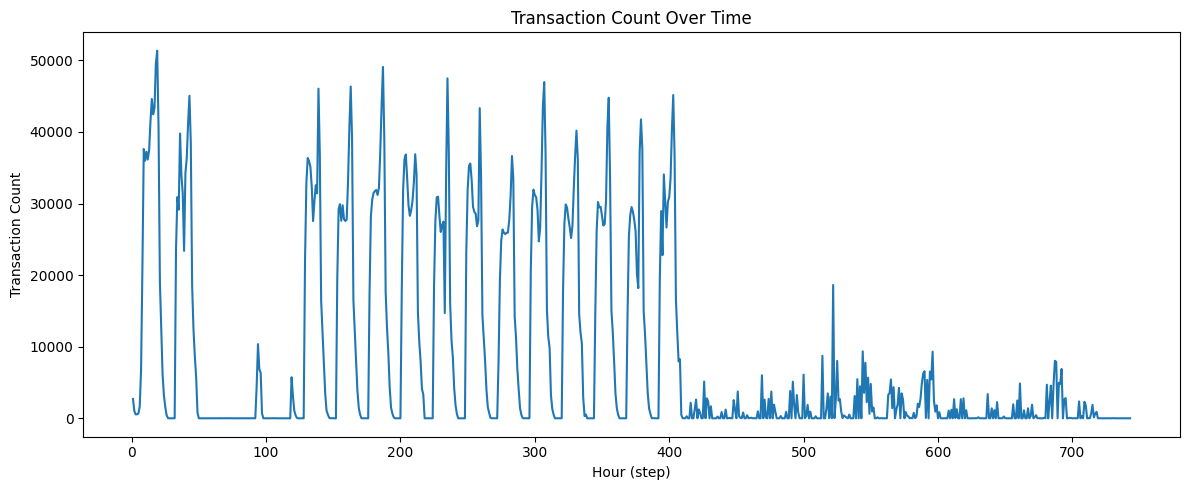

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_monitoring["hour"], hourly_monitoring["txn_count"])
plt.title("Transaction Count Over Time")
plt.xlabel("Hour (step)")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

## 32. Plotting fraud count over time

This chart focuses specifically on the number of fraudulent transactions observed in each hour.

While the earlier monitoring tables provide the exact values, the visual form makes it easier to spot visible changes, clusters, or bursts of fraud activity over time.

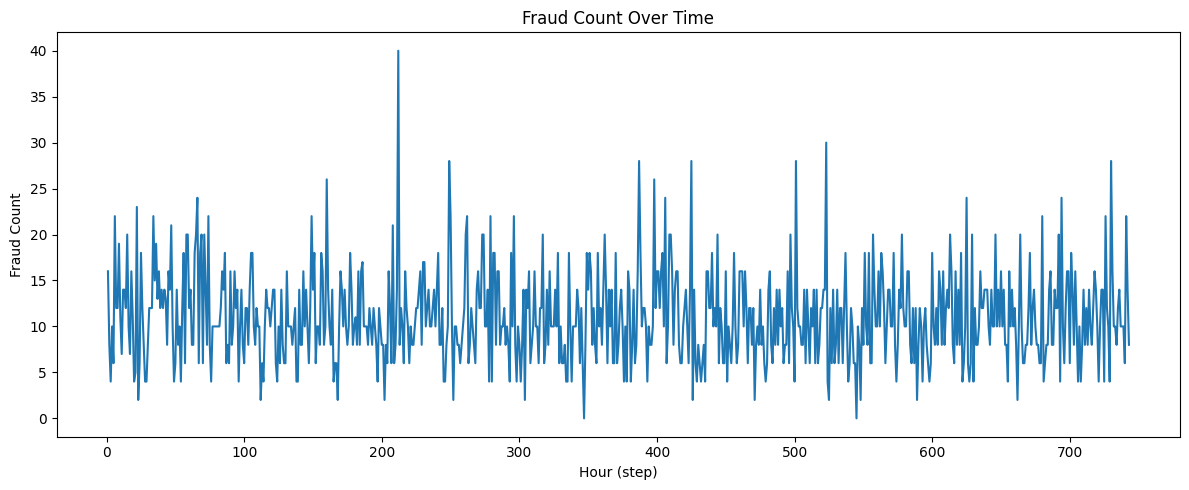

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_monitoring["hour"], hourly_monitoring["fraud_count"])
plt.title("Fraud Count Over Time")
plt.xlabel("Hour (step)")
plt.ylabel("Fraud Count")
plt.tight_layout()
plt.show()

## 33. Plotting fraud rate over time

Fraud count alone does not capture risk fully because overall transaction volume can vary.

This chart plots the

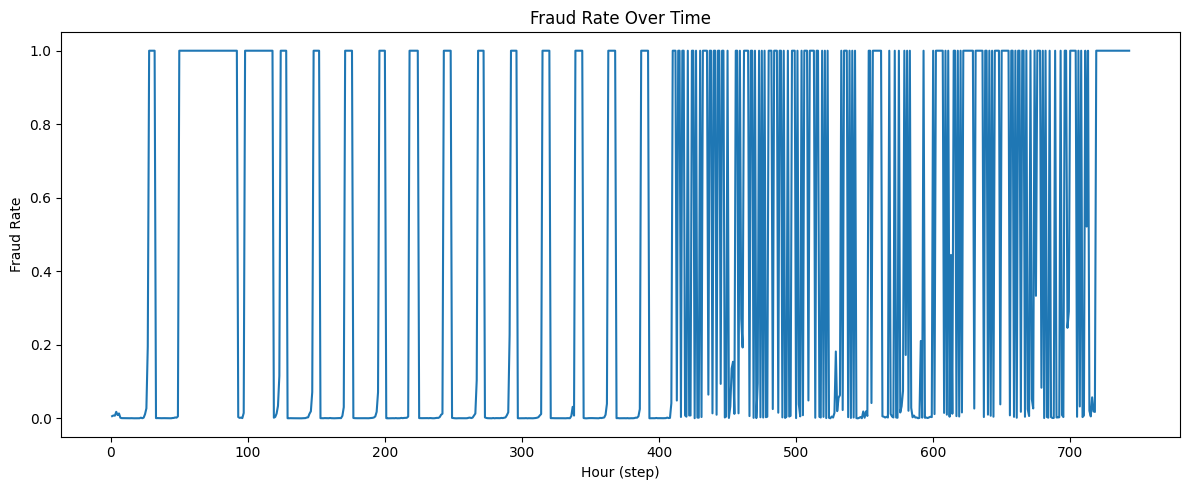

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_monitoring["hour"], hourly_monitoring["fraud_rate"])
plt.title("Fraud Rate Over Time")
plt.xlabel("Hour (step)")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

## 34. Visualizing the hourly fraud rate alongside its rolling average

This step turns the fraud-rate monitoring table into a chart that is easier to interpret visually.

Earlier in the notebook, the hourly monitoring table gave us the raw fraud rate for each step, and we also calculated a rolling 24-hour average. Both are useful, but they serve different purposes:

- the raw fraud rate shows the immediate hour-by-hour pattern
- the rolling mean smooths short-term noise and helps reveal the broader underlying trend

Placing both lines on the same chart makes it easier to distinguish between normal variation and more meaningful movement. A sharp gap between the raw series and the rolling baseline can signal an unusual risk period that may deserve further investigation.

This visualization is an important transition point in the notebook because it starts moving from descriptive tables into operational monitoring. Instead of only asking what the fraud rate is, we begin asking whether the current hour is behaving unusually relative to recent history.

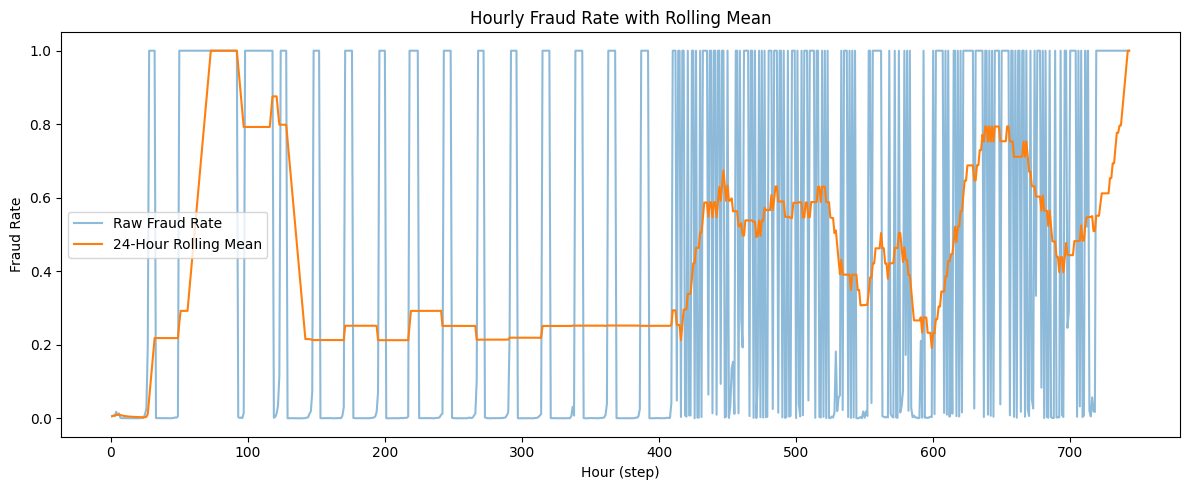

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_monitoring["hour"], hourly_monitoring["fraud_rate"], alpha=0.5, label="Raw Fraud Rate")
plt.plot(hourly_monitoring["hour"], hourly_monitoring["fraud_rate_roll_mean_24"], label="24-Hour Rolling Mean")
plt.title("Hourly Fraud Rate with Rolling Mean")
plt.xlabel("Hour (step)")
plt.ylabel("Fraud Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 35. Visualizing fraud rate by transaction type

This chart compares fraud risk across transaction types.

Earlier in the notebook, we created a transaction-type summary table that showed transaction volume, fraud counts, and fraud rates by type. This chart translates that table into a more intuitive visual comparison.

The purpose of this visualization is to answer a high-value business question:

Which transaction types are carrying the most fraud risk?

That question matters because fraud is not always distributed evenly across the transaction ecosystem. Some transaction types may be common but relatively safe, while others may be less common but much riskier. A fraud-operations team would care about this distinction because it helps determine where monitoring, controls, or investigation effort should be concentrated.

This chart should be interpreted as a **risk intensity comparison**, not just a volume comparison. A higher bar means a larger share of transactions in that category are fraudulent.

In this dataset, if only a few transaction types show visible non-zero bars, that is itself an important finding rather than a charting error. It indicates that fraud is concentrated rather than spread uniformly across all transaction categories.

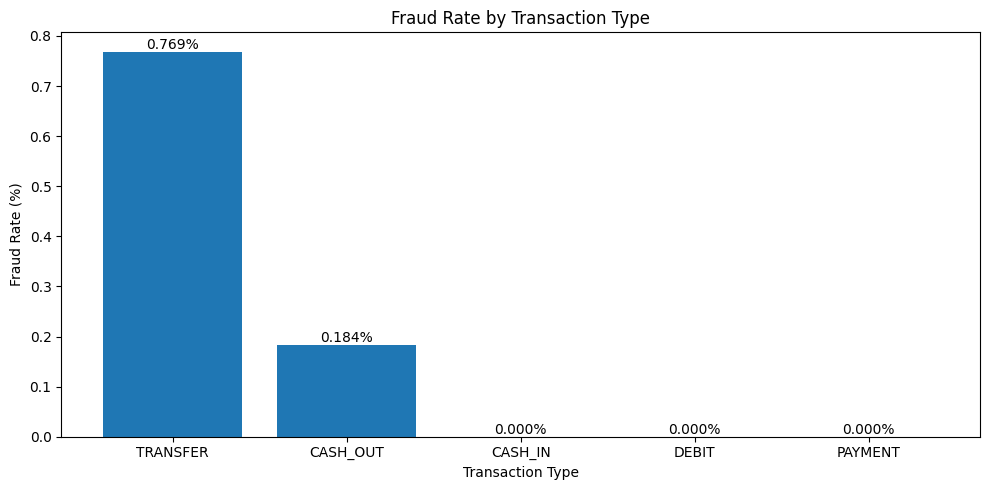

In [45]:
fraud_rate_by_type_for_plot = type_summary.sort_values("fraud_rate", ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    fraud_rate_by_type_for_plot["type"].astype(str),
    fraud_rate_by_type_for_plot["fraud_rate"] * 100
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

for bar, value in zip(bars, fraud_rate_by_type_for_plot["fraud_rate"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 36. Comparing fraud and non-fraud amount distributions on a log scale

This step compares the transaction-amount distributions for fraud and non-fraud records using a logarithmic transformation.

The raw `amount` variable in this dataset is highly skewed. A small number of very large transactions can dominate the scale and make the rest of the distribution difficult to read. If we plotted the raw amounts directly, the comparison between fraud and non-fraud behavior would be much less informative.

To solve that problem, this chart applies `log1p(amount)`, which compresses the upper tail while preserving order and making the overall shape easier to compare.

This chart is useful for answering questions such as:

- Do fraudulent transactions tend to be larger than non-fraud transactions?
- Are fraud amounts concentrated in a narrower range?
- Do fraud and non-fraud transactions have visibly different amount behavior?

This is one of the key exploratory comparisons in the notebook because amount behavior often becomes one of the strongest building blocks for later temporal and behavioral feature engineering.

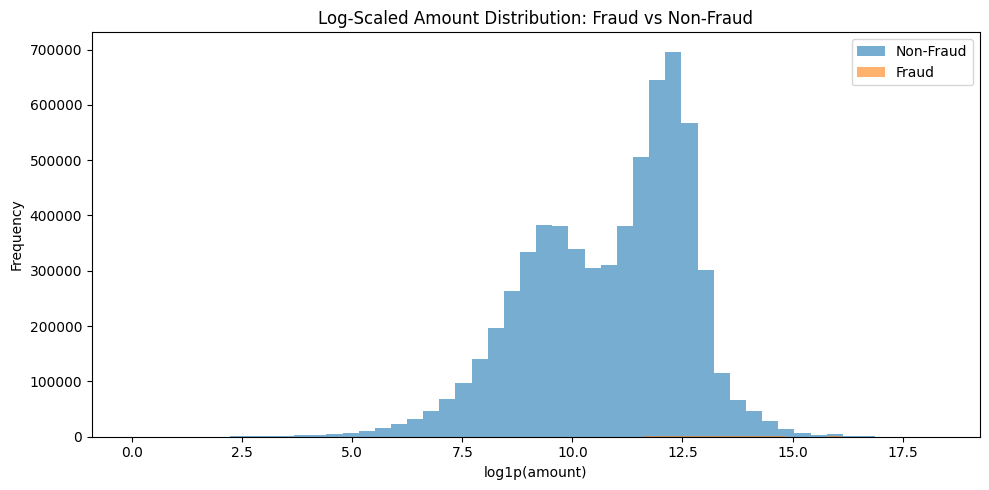

In [40]:
fraud_amounts = np.log1p(df.loc[df["isFraud"] == 1, "amount"])
nonfraud_amounts = np.log1p(df.loc[df["isFraud"] == 0, "amount"])

plt.figure(figsize=(10, 5))
plt.hist(nonfraud_amounts, bins=50, alpha=0.6, label="Non-Fraud")
plt.hist(fraud_amounts, bins=50, alpha=0.6, label="Fraud")
plt.title("Log-Scaled Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("log1p(amount)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 37. Saving the core monitoring and EDA outputs for later phases

This final step saves the main summary tables produced in this notebook to the project output folder.

This is an important engineering and workflow decision. The notebook has already performed several computationally meaningful steps on a dataset with more than 6.3 million rows. Recomputing all of these outputs every time would slow down future work and make the project less efficient.

By saving the outputs now, the project gains several advantages:

- later notebooks can reuse these results directly
- downstream analysis becomes faster and more reproducible
- the monitoring layer becomes a persistent project artifact rather than a temporary notebook view
- key business tables can be used later in the dashboard, README, or executive summary

The tables saved here include:

- overall dataset summary
- amount-distribution summary
- transaction-type risk summary
- fraud vs non-fraud profile summaries
- built-in flag versus actual fraud evaluation
- account-level behavior summaries
- hourly and daily monitoring tables
- transaction-type monitoring over time

In [41]:
overall_summary.to_csv(OUTPUT_DIR / "overall_summary.csv", index=False)
amount_distribution_summary.to_csv(OUTPUT_DIR / "amount_distribution_summary.csv", index=False)
type_summary.to_csv(OUTPUT_DIR / "type_summary.csv", index=False)
amount_by_fraud.to_csv(OUTPUT_DIR / "amount_by_fraud.csv", index=False)
fraud_profile.to_csv(OUTPUT_DIR / "fraud_profile.csv", index=False)
flag_vs_actual_counts.to_csv(OUTPUT_DIR / "flag_vs_actual_counts.csv")
flagged_fraud_evaluation.to_csv(OUTPUT_DIR / "flagged_fraud_evaluation.csv", index=False)
flagged_vs_actual_by_type.to_csv(OUTPUT_DIR / "flagged_vs_actual_by_type.csv", index=False)
origin_account_summary.to_csv(OUTPUT_DIR / "origin_account_summary.csv", index=False)
destination_account_summary.to_csv(OUTPUT_DIR / "destination_account_summary.csv", index=False)
hourly_monitoring.to_csv(OUTPUT_DIR / "hourly_monitoring.csv", index=False)
daily_monitoring.to_csv(OUTPUT_DIR / "daily_monitoring.csv", index=False)
hourly_type_monitoring.to_csv(OUTPUT_DIR / "hourly_type_monitoring.csv", index=False)
daily_type_monitoring.to_csv(OUTPUT_DIR / "daily_type_monitoring.csv", index=False)

print(f"Saved Phase 3 outputs to: {OUTPUT_DIR}")

Saved Phase 3 outputs to: /Users/twon/Documents/Time Series Analysis Project/data/outputs/phase_3_eda_monitoring


## Conclusion

This notebook completed the exploratory and monitoring stage of the project.

At this point, the project has moved beyond structural validation and into behavioral understanding. The analysis now covers:

- overall transaction and fraud activity
- transaction-type concentration of risk
- amount behavior for fraud and non-fraud transactions
- account-level activity patterns
- hourly and daily monitoring views
- rolling fraud-rate behavior
- early spike detection logic
- saved monitoring outputs for downstream use

This phase is important because it creates the analytical bridge between raw data quality checks and later feature engineering. The goal was not only to describe the dataset, but to begin identifying where risk is concentrated, how it behaves over time, and which patterns may later be converted into transaction-level predictive features.

The next notebook should build on these findings by engineering temporal and behavioral features using only historically available information. That next step must be handled carefully to avoid future leakage and to preserve the realism of the fraud-monitoring workflow. :contentReference[oaicite:2]{index=2} :contentReference[oaicite:3]{index=3}